In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
%matplotlib inline
from pandas import DataFrame
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import math
import os

In [2]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

nsim = 10 # number of simulations

In [3]:
# Weights (unphos)

p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [4]:
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [5]:
ctd_p = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/ser5_dist/dat/ser5_ser7_dist.dat', sep = r'\s+')
#ctd = ctd.drop(['1-23[Max]'],axis=1)

In [6]:
pmean = np.average(ctd_p['SEP12-ASN14'], weights=p_ctd_weights_combined[0])

pstd = np.sqrt(np.cov(ctd_p['SEP12-ASN14'], aweights=p_ctd_weights_combined[0]))

print("pmean: {}".format(pmean))
print("pstd: {}".format(pstd))

# ctd_p

pmean: 6.802861809480879
pstd: 1.1483710306858912


In [7]:
# ctd_p



phosphoryalted vs unphosphorylated

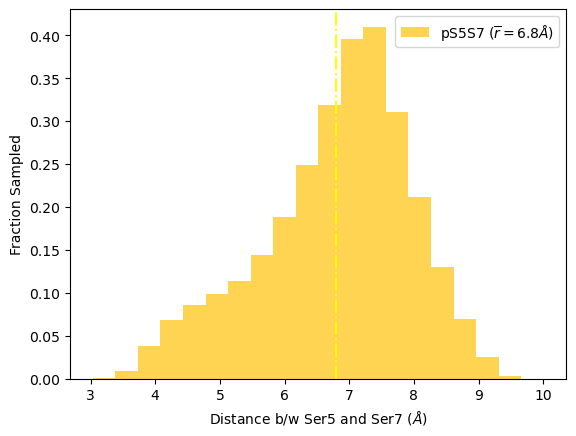

In [8]:
#binedges = np.arange(6,20,0.5)

#plt.hist(ctd['1-23'], bins = binedges, weights = ctd_weights_combined[0], density=True , color="#0C7BDC", label=r"CTD Unphos ($\overline{r} = $"+"{})".format(round(npmean, 2)), alpha=0.6)
plt.hist(ctd_p['SEP12-ASN14'], bins=20, weights = p_ctd_weights_combined[0], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('Distance b/w Ser5 and Ser7 ($\AA$)')
#plt.title('Radius of Gyration (Con)')
plt.legend(loc="upper right", fontsize=10)
plt.show()
# filename = "radgyr_asn_1.pdf"
# path="/home/wbarr/data/ctd_project/Figure_July_2023/"    # remember to have a trailing '/' !!!!

# overwrite = False

# if not overwrite and os.path.exists(path + filename):
#     raise FileExistsError("File already exists and overwrite is set to False.")
# else:
#     plt.savefig(path + filename, format="pdf", bbox_inches="tight")
#     plt.show()
#     print("File Saved.")

In [9]:
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')

In [10]:
ctd_phos_omega_angles_raw.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
0,1,169.3774,154.5425,177.9407,-159.0253,-115.0219,-160.7111,151.5470,-174.0180,143.9142,...,-168.1344,147.0311,174.0354,-161.0518,-163.7683,139.4358,178.9275,-173.1329,-79.0204,-163.3891
1,2,-167.9550,162.2740,-170.2504,-165.5033,-129.9617,-155.3179,156.1463,-177.2399,148.1583,...,177.2767,163.1209,155.9706,-168.2798,-167.4301,125.9587,154.3336,-165.0549,-51.3273,177.4639
2,3,-171.2658,159.7665,-175.0056,-173.6953,-129.4725,-161.8132,160.8489,170.7050,155.0069,...,-173.8997,154.1444,176.4044,-163.7985,-155.6609,136.8017,156.9786,-170.3209,-53.9733,158.9358
3,4,155.5256,154.4582,-163.4627,-173.0678,-143.3403,-149.9780,167.4560,153.8272,150.4389,...,-170.7282,154.3431,172.3705,179.6981,-177.7641,141.6324,173.7510,-167.1643,-18.0790,168.0553
4,5,156.2701,142.4849,-160.8785,-174.4625,-138.7235,-163.5336,167.0651,146.2143,152.5562,...,175.0221,158.5930,-178.2579,170.2890,-165.0234,147.8316,164.2243,173.3470,-36.5980,178.9990


In [11]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

In [12]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()

In [13]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_1452593/1419004987.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [14]:
ctd_p = ctd_p.reset_index(drop=True)
ctd_p_cistrans = ctd_p.copy()
ctd_p_cistrans['cis/trans/neither'] = ctd_phos_omega_angles['omega:14']

In [15]:
ctd_p_cistrans['weights'] = p_ctd_weights_combined[0]

In [16]:
ctd_p_cistrans.head()

,#Frame,SEP12-ASN14,cis/trans/neither,weights
0,1,6.7946,trans,3.353254e-08
1,2,6.7227,trans,1.815629e-08
2,3,6.8851,trans,1.478031e-08
3,4,7.0208,trans,1.911366e-08
4,5,7.0898,trans,2.361327e-08


In [17]:
ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis']

,#Frame,SEP12-ASN14,cis/trans/neither,weights
66424,66425,7.1127,cis,2.715128e-08
66431,66432,7.2073,cis,2.045896e-08
68529,68530,7.6203,cis,1.371847e-08
69101,69102,7.2923,cis,1.155476e-08
137369,137370,6.8508,cis,3.267283e-09
...,...,...,...,...
48987669,48987670,6.6662,cis,1.155282e-08
48987673,48987674,6.4672,cis,1.199700e-08
48987683,48987684,6.8750,cis,5.451464e-09
48987689,48987690,7.1028,cis,2.608441e-08


In [18]:
ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans']

,#Frame,SEP12-ASN14,cis/trans/neither,weights
0,1,6.7946,trans,3.353254e-08
1,2,6.7227,trans,1.815629e-08
2,3,6.8851,trans,1.478031e-08
3,4,7.0208,trans,1.911366e-08
4,5,7.0898,trans,2.361327e-08
...,...,...,...,...
48999995,48999996,6.4373,trans,2.587961e-08
48999996,48999997,6.8247,trans,6.309915e-09
48999997,48999998,6.8249,trans,1.065208e-08
48999998,48999999,6.4050,trans,3.464288e-08


## Pro6 in cis

In [19]:
pmean_cis = np.average((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-ASN14'], weights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights'])

pstd_cis = np.sqrt(np.cov((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-ASN14'], aweights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("pmean: {}".format(pmean))
print("pstd: {}".format(pstd))

pmean: 6.802861809480879
pstd: 1.1483710306858912


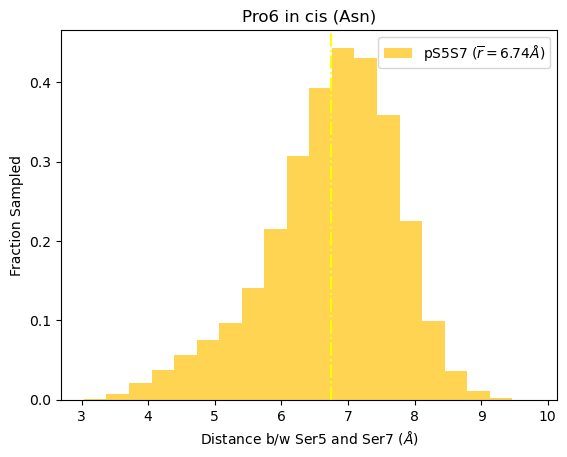

In [20]:
plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-ASN14'], bins=20, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_cis, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_cis, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('Distance b/w Ser5 and Ser7 ($\AA$)')
plt.title('Pro6 in cis (Asn)')
plt.legend(loc="upper right", fontsize=10)
plt.show()

## Pro6 in trans

In [21]:
pmean_trans = np.average((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-ASN14'], weights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights'])

pstd_trans = np.sqrt(np.cov((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-ASN14'], aweights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("pmean: {}".format(pmean))
print("pstd: {}".format(pstd))

pmean: 6.802861809480879
pstd: 1.1483710306858912


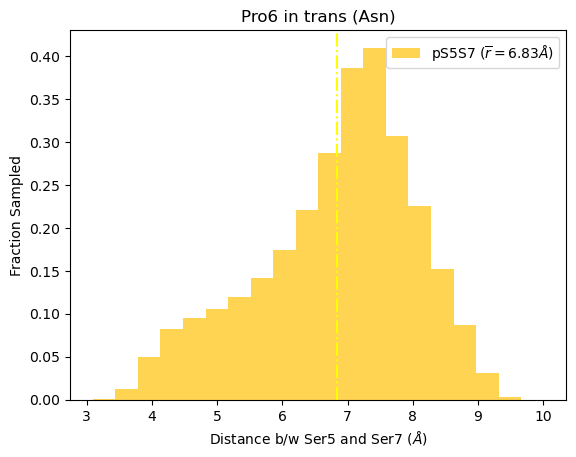

In [22]:
plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-ASN14'], bins=20, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_trans, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_trans, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('Distance b/w Ser5 and Ser7 ($\AA$)')
plt.title('Pro6 in trans (Asn)')
plt.legend(loc="upper right", fontsize=10)
plt.show()

## cis and trans together

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


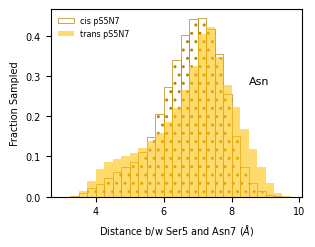

In [24]:
binedges = np.arange(3,10,0.25)

n_density_cis, bins_cis, _cis = plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-ASN14'], edgecolor='darkgoldenrod', bins=binedges, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color = '#FFC20A', hatch='..', linewidth=0.5, fill=None, label=r"cis pS5N7".format(round(pmean_cis, 2)), alpha=1)

#plt.axvline(npmean, color='steelblue', ls='--')
#plt.axvline(pmean_cis, color='yellow', ls='--')

n_density_trans, bins_trans, _trans = plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-ASN14'], bins=binedges, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", linewidth=0.5, label=r"trans pS5N7".format(round(pmean_trans, 2)), alpha=0.6)

#plt.axvline(npmean, color='steelblue', ls='--')
#plt.axvline(pmean_trans, color='yellow', ls='-.')

#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled', fontsize=7)
plt.xlabel('Distance b/w Ser5 and Asn7 ($\AA$)', fontsize=7)
#plt.title('Asparagine Phosphorylated')
plt.legend(loc="upper left", fontsize=5.75, frameon=False)
plt.text(8.5, 0.3, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('pS5-N7_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

In [25]:
# Set the threshold
threshold = 6

# Find the index of the first bin edge >= threshold
above_threshold_index = np.where(bins_cis >= threshold)[0][0]

# Sum the densities of the bins_cis above the threshold
sum_of_densities = np.sum(n_density_cis[above_threshold_index:])

# Calculate the width of a single bin
bin_width = bins_cis[1] - bins_cis[0]

# Calculate the proportion (percentage) of values above the threshold
# The proportion is the sum of the areas of the relevant bars
percentage_above_threshold = (sum_of_densities * bin_width) * 100

print(f"The total proportion (area) above {threshold} is: {sum_of_densities * bin_width:.2f}")
print(f"The percentage of values above {threshold} is: {percentage_above_threshold:.2f}%")

The total proportion (area) above 6 is: 0.80
The percentage of values above 6 is: 80.08%


In [26]:
# Set the threshold
threshold = 6

# Find the index of the first bin edge >= threshold
above_threshold_index = np.where(bins_trans >= threshold)[0][0]

# Sum the densities of the bins_trans above the threshold
sum_of_densities = np.sum(n_density_trans[above_threshold_index:])

# Calculate the width of a single bin
bin_width = bins_trans[1] - bins_trans[0]

# Calculate the proportion (percentage) of values above the threshold
# The proportion is the sum of the areas of the relevant bars
percentage_above_threshold = (sum_of_densities * bin_width) * 100

print(f"The total proportion (area) above {threshold} is: {sum_of_densities * bin_width:.2f}")
print(f"The percentage of values above {threshold} is: {percentage_above_threshold:.2f}%")

The total proportion (area) above 6 is: 0.77
The percentage of values above 6 is: 76.69%
